In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/3
    print("準備完了！このまま下のセルを実行できます。")

# 第3章 基本分布 (Standard Distributions)
## 3.4 指数型分布族 (The Exponential Family)

本ノートブックでは、パターン認識と機械学習において極めて中心的な役割を果たす**指数型分布族 (The Exponential Family)** の数学的定式化、主要な確率分布（ベルヌーイ分布、多項分布、ガウス分布、フォン・ミーゼス分布）の正準形式表現、そして **3.4.1 十分統計量 (Sufficient Statistics)** と最尤推定の幾何学的・計算論的性質を包括的に実装・検証します。

---

### 目次
1. **3.4 指数型分布族の一般定式化 (General Formulation)**
   - 表現形式と構成要素（自然パラメータ $oldsymbol{\eta}$、十分統計量 $\mathbf{u}(\mathbf{x})$、基底測度 $h(\mathbf{x})$、対数分配関数 $A(oldsymbol{\eta})$）
2. **主要分布の正準形式への還元**
   - ベルヌーイ分布 (Bernoulli) とロジット／シグモイド連結
   - 多項分布 (Multinomial) とソフトマックス写像（非冗長表現）
   - 1次元・多変量ガウス分布 (Gaussian) と負の半平面制約
   - フォン・ミーゼス分布 (Von Mises) と円周統計量
3. **3.4.1 十分統計量 (Sufficient Statistics) とキュムラント母関数**
   - 規格化条件からの微分による平均 $\mathbb{E}[\mathbf{u}(\mathbf{x})] = 
abla A(oldsymbol{\eta})$ の導出
   - 2階微分による共分散行列 $\mathrm{cov}[\mathbf{u}(\mathbf{x})] = 
abla^2 A(oldsymbol{\eta})$ と狭義凸性の証明
   - 最尤推定量 (MLE) の十分統計量による完全決定方程式
   - オンライン／ストリーミング学習における $\mathcal{O}(1)$ メモリ効率性
4. **教科書図の実装と可視化**
   - **Figure 3.13**: 指数型分布族の幾何構造（狭義凸性、支持超平面、双対写像、曲率と分散）
   - **Figure 3.14**: 主要構成員の自然パラメータ空間と正準写像
   - **Figure 3.15**: 十分統計量によるオンライン逐次推定とデータ圧縮
5. **自己検証アサーション (Self-Check Assertions)**


In [1]:
import os
import sys
import numpy as np
import scipy.linalg as la
from scipy import special
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.append(repo_root)

from common.plot_utils import setup_style
from common.probability import (
    ExponentialFamilyBase,
    BernoulliExponential,
    GaussianExponential1D,
    MultinomialExponential,
    VonMisesExponential,
    plot_figure_3_13_exp_family_geometry,
    plot_figure_3_14_exp_family_members,
    plot_figure_3_15_sufficient_statistics_online
)

setup_style()
print("Libraries and exponential family modules loaded successfully.")


Libraries and exponential family modules loaded successfully.


---
## 1. 指数型分布族の一般定式化 (General Formulation)

変数 $\mathbf{x}$ 上のパラメータ $\boldsymbol{\eta}$ をもつ確率分布族のうち、以下の形で表現できる確率密度（または離散確率質量）を**指数型分布族 (The Exponential Family)** と呼びます（式 3.138）：

$$
p(\mathbf{x} \mid \boldsymbol{\eta}) = h(\mathbf{x}) \, g(\boldsymbol{\eta}) \exp\left( \boldsymbol{\eta}^T \mathbf{u}(\mathbf{x}) \right)
$$

ここで各構成要素の定義と物理的・情報幾何的意味は以下の通りです：
- $\boldsymbol{\eta}$: **自然パラメータ (natural parameters)** または正準パラメータ (canonical parameters) のベクトル
- $\mathbf{u}(\mathbf{x})$: 観測値 $\mathbf{x}$ の非線形変換からなる **十分統計量 (sufficient statistics)** のベクトル
- $h(\mathbf{x})$: 観測空間の基本尺度（**基底測度: base measure**）
- $g(\boldsymbol{\eta})$: 全空間での積分（または総和）を $1$ にするための **規格化係数 (normalizer coefficient)**

分布の全確率保存則 $\int p(\mathbf{x} \mid \boldsymbol{\eta}) d\mathbf{x} = 1$ より、規格化係数は次を満たします（式 3.139）：
$$
g(\boldsymbol{\eta}) \int h(\mathbf{x}) \exp\left( \boldsymbol{\eta}^T \mathbf{u}(\mathbf{x}) \right) d\mathbf{x} = 1
$$

### 対数分配関数 (Log-Partition Function / Cumulant Function)
規格化係数の対数の負数を $A(\boldsymbol{\eta}) \equiv -\ln g(\boldsymbol{\eta})$ と定義すると、分布は次のように書き直せます：
$$
p(\mathbf{x} \mid \boldsymbol{\eta}) = h(\mathbf{x}) \exp\left( \boldsymbol{\eta}^T \mathbf{u}(\mathbf{x}) - A(\boldsymbol{\eta}) \right)
$$
物理学（統計力学）における**自由エネルギー**に相当し、統計学ではモーメント・キュムラントを生み出す**キュムラント母関数 (cumulant generating function)** として中心的な役割を担います。


---
## 2. 主要分布の指数型分布族としての表現

### 2.1 ベルヌーイ分布 (Bernoulli Distribution)
二値変数 $x \in \{0, 1\}$ に対し、成功確率 $\mu = p(x=1)$ をもつベルヌーイ分布は通常次のように表されます（式 3.140）：
$$
p(x \mid \mu) = \mu^x (1 - \mu)^{1 - x} = \exp\left( x \ln \mu + (1 - x) \ln(1 - \mu) \right)
$$
これを指数関数の形で整理すると（式 3.141 - 3.143）：
$$
p(x \mid \mu) = (1 - \mu) \exp\left( \ln\left(\frac{\mu}{1 - \mu}\right) x \right)
$$
指数型分布族の正準形 $p(x \mid \eta) = h(x) g(\eta) \exp(\eta u(x))$ と比較することにより：
- **自然パラメータ**: $\eta = \ln\left(\frac{\mu}{1 - \mu}\right)$ （**ロジット関数: logit function**）
- **逆写像（平均パラメータ）**: $\mu = \sigma(\eta) = \frac{1}{1 + e^{-\eta}}$ （**ロジスティック・シグモイド関数: logistic sigmoid**）
- **十分統計量**: $u(x) = x$
- **基底測度**: $h(x) = 1$
- **規格化係数**: $g(\eta) = 1 - \mu = 1 - \sigma(\eta) = \sigma(-\eta) = \frac{1}{1 + e^\eta}$
- **対数分配関数**: $A(\eta) = -\ln g(\eta) = \ln(1 + e^\eta)$ （**ソフトプラス関数: softplus function**）


In [2]:
# ベルヌーイ分布の正準形式と対数分配関数の数値検証
mu_true = 0.72
dist_bern = BernoulliExponential(mu=mu_true)

print(f"Mean parameter mu: {dist_bern.mu:.4f}")
print(f"Natural parameter eta = log(mu / (1-mu)): {dist_bern.eta:.4f}")

# 1階微分の検証: A'(eta) = mu = E[x]
grad_A = dist_bern.grad_log_partition()
print(f"grad A(eta) = sigma(eta): {grad_A:.4f} (Expected: {mu_true:.4f})")

# 2階微分の検証: A''(eta) = Var[x] = mu*(1-mu)
hess_A = dist_bern.hessian_log_partition()
expected_var = mu_true * (1.0 - mu_true)
print(f"hessian A(eta) = Var[x]: {hess_A:.4f} (Expected: {expected_var:.4f})")

assert np.isclose(grad_A, mu_true)
assert np.isclose(hess_A, expected_var)


Mean parameter mu: 0.7200
Natural parameter eta = log(mu / (1-mu)): 0.9445
grad A(eta) = sigma(eta): 0.7200 (Expected: 0.7200)
hessian A(eta) = Var[x]: 0.2016 (Expected: 0.2016)


### 2.2 多項分布 (Multinomial Distribution)
$M$ 個の状態をとるカテゴリカル分布（1-of-$M$ 表現 $\mathbf{x} = (x_1, \dots, x_M)^T, \sum x_k = 1$）において、パラメータは $\sum_{k=1}^M \mu_k = 1$ の拘束を受けます。
拘束を明示的に解くため、冗長なパラメータ $\mu_M = 1 - \sum_{k=1}^{M-1} \mu_k$ を消去すると（式 3.155 - 3.157）：

$$
p(\mathbf{x} \mid \boldsymbol{\mu}) = \exp\left( \sum_{k=1}^{M} x_k \ln \mu_k \right) = \exp\left( \sum_{k=1}^{M-1} x_k \ln\left(\frac{\mu_k}{\mu_M}\right) + \ln \mu_M \right)
$$
これにより、$M-1$ 次元の独立な正準形式が得られます：
- **自然パラメータ**: $\eta_k = \ln\left(\frac{\mu_k}{\mu_M}\right) \quad (k = 1, \dots, M-1)$
- **逆写像（ソフトマックス関数）**:
  $$
  \mu_k = \frac{\exp(\eta_k)}{1 + \sum_{j=1}^{M-1} \exp(\eta_j)}, \quad \mu_M = \frac{1}{1 + \sum_{j=1}^{M-1} \exp(\eta_j)}
  $$
- **十分統計量**: $\mathbf{u}(\mathbf{x}) = (x_1, \dots, x_{M-1})^T$
- **対数分配関数**: $A(\boldsymbol{\eta}) = \ln\left(1 + \sum_{k=1}^{M-1} \exp(\eta_k)\right)$


In [3]:
# 多項分布の正準形式とソフトマックス逆写像の検証
mu_cat = np.array([0.2, 0.5, 0.3])
dist_multi = MultinomialExponential(mu=mu_cat)

print(f"Target probabilities: {mu_cat}")
print(f"Natural parameters eta_1, eta_2: {dist_multi.eta}")
print(f"Recovered probabilities via Softmax: {dist_multi.mu}")

grad_multi = dist_multi.grad_log_partition()
hess_multi = dist_multi.hessian_log_partition()

print(f"Gradient grad A(eta): {grad_multi} (matches mu_1, mu_2)")
print(f"Hessian eigenvalues: {la.eigvalsh(hess_multi)} (strictly positive definite)")

assert np.allclose(grad_multi, mu_cat[:-1])
assert np.all(la.eigvalsh(hess_multi) > 0)


Target probabilities: [0.2 0.5 0.3]
Natural parameters eta_1, eta_2: [-0.40546511  0.51082562]
Recovered probabilities via Softmax: [0.2 0.5 0.3]
Gradient grad A(eta): [0.2 0.5] (matches mu_1, mu_2)
Hessian eigenvalues: [0.09534144 0.31465856] (strictly positive definite)


### 2.3 1次元ガウス分布 (Univariate Gaussian)
平均 $\mu$、分散 $\sigma^2$ の1次元正規分布（式 3.162）：
$$
p(x \mid \mu, \sigma^2) = \frac{1}{(2\pi\sigma^2)^{1/2}} \exp\left( -\frac{1}{2\sigma^2}(x - \mu)^2 \right)
= \frac{1}{(2\pi)^{1/2}} \exp\left( \frac{\mu}{\sigma^2} x - \frac{1}{2\sigma^2} x^2 - \frac{\mu^2}{2\sigma^2} - \frac{1}{2}\ln \sigma^2 \right)
$$
正準形式 $h(x) g(\boldsymbol{\eta}) \exp(\boldsymbol{\eta}^T \mathbf{u}(x))$ と照合すると（式 3.163 - 3.167）：
- **自然パラメータ**:
  $$
  \boldsymbol{\eta} = \begin{pmatrix} \eta_1 \\ \eta_2 \end{pmatrix} = \begin{pmatrix} \frac{\mu}{\sigma^2} \\ -\frac{1}{2\sigma^2} \end{pmatrix} \quad (\text{制約: } \eta_2 < 0)
  $$
- **標準パラメータの復元**:
  $$
  \sigma^2 = -\frac{1}{2\eta_2}, \quad \mu = -\frac{\eta_1}{2\eta_2}
  $$
- **十分統計量**: $\mathbf{u}(x) = \begin{pmatrix} x \\ x^2 \end{pmatrix}$
- **基底測度**: $h(x) = (2\pi)^{-1/2}$
- **対数分配関数**:
  $$
  A(\boldsymbol{\eta}) = -\frac{1}{2}\ln(-2\eta_2) - \frac{\eta_1^2}{4\eta_2}
  $$


In [4]:
# ガウス分布の自然パラメータと対数分配関数の検証
dist_gauss = GaussianExponential1D(mu=2.5, sigma2=1.44)

print(f"Standard parameters: mu = {dist_gauss.mu}, sigma^2 = {dist_gauss.sigma2}")
print(f"Natural parameters: eta = {dist_gauss.eta}")

# 勾配の検証: grad A(eta) = E[u(x)] = [E[x], E[x^2]] = [mu, mu^2 + sigma^2]
grad_gauss = dist_gauss.grad_log_partition()
expected_grad_gauss = np.array([dist_gauss.mu, dist_gauss.mu**2 + dist_gauss.sigma2])
print(f"grad A(eta) = {grad_gauss}")
print(f"Expected E[u(x)] = {expected_grad_gauss}")

# ヘッセ行列の検証: Hessian A(eta) = Cov[u(x)]
hess_gauss = dist_gauss.hessian_log_partition()
print("Hessian A(eta):")
print(hess_gauss)
print("Hessian Eigenvalues:", la.eigvalsh(hess_gauss))

assert np.allclose(grad_gauss, expected_grad_gauss)
assert np.all(la.eigvalsh(hess_gauss) > 0)


Standard parameters: mu = 2.5, sigma^2 = 1.44
Natural parameters: eta = [ 1.73611111 -0.34722222]
grad A(eta) = [2.5  7.69]
Expected E[u(x)] = [2.5  7.69]
Hessian A(eta):
[[ 1.44    7.2   ]
 [ 7.2    40.1472]]
Hessian Eigenvalues: [ 0.14410042 41.44309958]


---
## 3. 3.4.1 十分統計量 (Sufficient Statistics)

### 3.1 期待値と共分散の導出 (Derivation of Moments)
指数型分布族の最も顕著な性質の一つは、対数分配関数 $A(\boldsymbol{\eta})$ の導関数を計算するだけで、十分統計量 $\mathbf{u}(\mathbf{x})$ のすべてのモーメントが解析的に得られることです。

#### (1) 1階微分と期待値 $\mathbb{E}[\mathbf{u}(\mathbf{x})]$
規格化条件 $\exp(A(\boldsymbol{\eta})) = \int h(\mathbf{x}) \exp(\boldsymbol{\eta}^T \mathbf{u}(\mathbf{x})) d\mathbf{x}$ の両辺を $\boldsymbol{\eta}$ で勾配を取ると：
$$
\nabla A(\boldsymbol{\eta}) \exp(A(\boldsymbol{\eta})) = \int h(\mathbf{x}) \exp(\boldsymbol{\eta}^T \mathbf{u}(\mathbf{x})) \mathbf{u}(\mathbf{x}) d\mathbf{x}
$$
両辺を $\exp(A(\boldsymbol{\eta}))$ で割ると、右辺はまさに確率密度 $p(\mathbf{x} \mid \boldsymbol{\eta})$ による $\mathbf{u}(\mathbf{x})$ の期待値となります（式 3.149）：
$$
\nabla A(\boldsymbol{\eta}) = -\nabla \ln g(\boldsymbol{\eta}) = \mathbb{E}[\mathbf{u}(\mathbf{x})]
$$

#### (2) 2階微分と共分散行列 $\mathrm{cov}[\mathbf{u}(\mathbf{x})]$
さらに両辺を $\boldsymbol{\eta}$ で微分（ヘッセ行列）すると（式 3.151）：
$$
\nabla^2 A(\boldsymbol{\eta}) = \mathbb{E}[\mathbf{u}(\mathbf{x})\mathbf{u}(\mathbf{x})^T] - \mathbb{E}[\mathbf{u}(\mathbf{x})]\mathbb{E}[\mathbf{u}(\mathbf{x})]^T = \mathrm{cov}[\mathbf{u}(\mathbf{x})]
$$
共分散行列は定義により非負定値であり、表現が最小（パラメータ間に冗長性がない）ならば**狭義正定値**となります：
$$
\nabla^2 A(\boldsymbol{\eta}) \succ 0 \implies A(\boldsymbol{\eta}) \text{ は自然パラメータ } \boldsymbol{\eta} \text{ について狭義凸 (strictly convex)}
$$

---

### 3.2 最尤推定 (Maximum Likelihood Estimation)
独立同分布 (i.i.d.) なデータ集合 $X = \{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ に対する対数尤度関数は次のように書けます（式 3.152）：
$$
\ln p(X \mid \boldsymbol{\eta}) = \sum_{n=1}^N \ln h(\mathbf{x}_n) - N A(\boldsymbol{\eta}) + \boldsymbol{\eta}^T \left(\sum_{n=1}^N \mathbf{u}(\mathbf{x}_n)\right)
$$
対数尤度を自然パラメータ $\boldsymbol{\eta}$ について最大化するため、勾配をゼロとおきます：
$$
\nabla \ln p(X \mid \boldsymbol{\eta}) = -N \nabla A(\boldsymbol{\eta}) + \sum_{n=1}^N \mathbf{u}(\mathbf{x}_n) = \mathbf{0}
$$
したがって、最尤解 $\boldsymbol{\eta}^{\mathrm{ML}}$ を満たす基本方程式が得られます（式 3.154）：
$$
\nabla A(\boldsymbol{\eta}^{\mathrm{ML}}) = \frac{1}{N} \sum_{n=1}^N \mathbf{u}(\mathbf{x}_n)
$$
**重要な結論（ピットマン・クープマン・ダルモアの定理の系）**:
- 最尤推定量 $\boldsymbol{\eta}^{\mathrm{ML}}$ は、データ集合 $X$ のうち**十分統計量の標本平均 $\frac{1}{N}\sum \mathbf{u}(\mathbf{x}_n)$ のみに依存**します。
- データが何百万件あっても、それらを個別に保持する必要はなく、低次元の十分統計量の総和ベクトル $\sum \mathbf{u}(\mathbf{x}_n)$ さえ保持すれば、情報損失ゼロで最尤推定が実行可能です（**データ圧縮・ストリーミング処理**）。


Figure 3.13 saved successfully to: result/fig3_13_exp_family_geometry.png


Figure 3.13 saved successfully to: ../result/fig3_13_exp_family_geometry.png


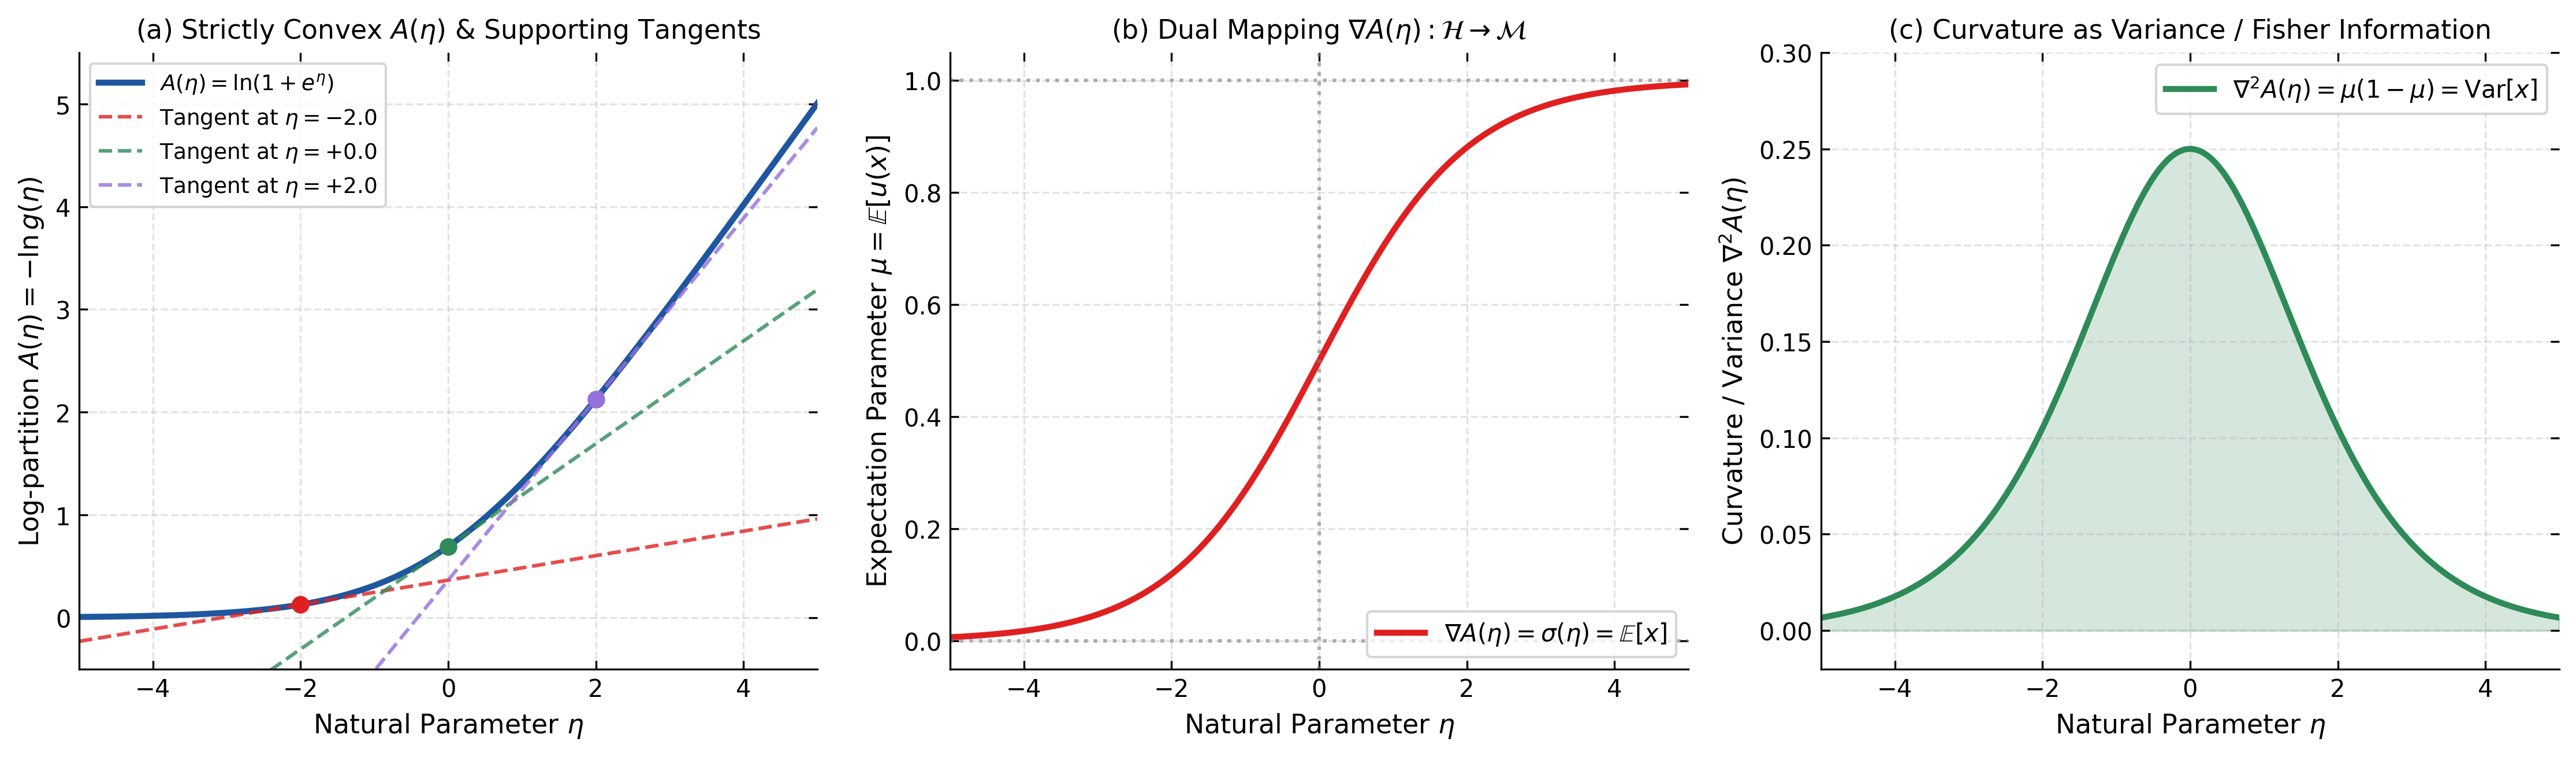

In [5]:
# Figure 3.13: 指数型分布族の幾何構造の描画
fig13, axes13 = plot_figure_3_13_exp_family_geometry(
    save_paths=["result/fig3_13_exp_family_geometry.png", "../result/fig3_13_exp_family_geometry.png"],
    show=True
)


### Figure 3.13 の幾何学的考察
- **(a) 対数分配関数 $A(\eta)$ の狭義凸性と支持超平面 (Supporting Tangents)**:
  $A(\eta) = \ln(1 + e^\eta)$ は全域で下に凸（狭義凸）であり、任意の点 $\eta_0$ における接線は常にグラフの下側に位置します。この凸性がルジャンドル変換（Legendre transformation）を通じた情報幾何（双対座標系）の基礎を成します。
- **(b) 双対写像 $\nabla A(\eta): \mathcal{H} \to \mathcal{M}$**:
  自然パラメータ空間 $\mathcal{H} = \mathbb{R}$ から期待値パラメータ空間 $\mathcal{M} = (0, 1)$ への写像は、狭義単調増加なシグモイド関数 $\mu = \sigma(\eta)$ となり、単射かつ全射（1対1対応）です。
- **(c) 曲率と分散（フィッシャー情報量）**:
  2階微分 $\nabla^2 A(\eta) = \mu(1 - \mu)$ は確率変数の分散であり、同時にモデルのフィッシャー情報量 $I(\eta)$ に一致します。$\eta = 0$ ($\mu = 0.5$) で分散が最大値 $0.25$ を取ることが確認できます。


Figure 3.14 saved successfully to: result/fig3_14_exp_family_members.png


Figure 3.14 saved successfully to: ../result/fig3_14_exp_family_members.png


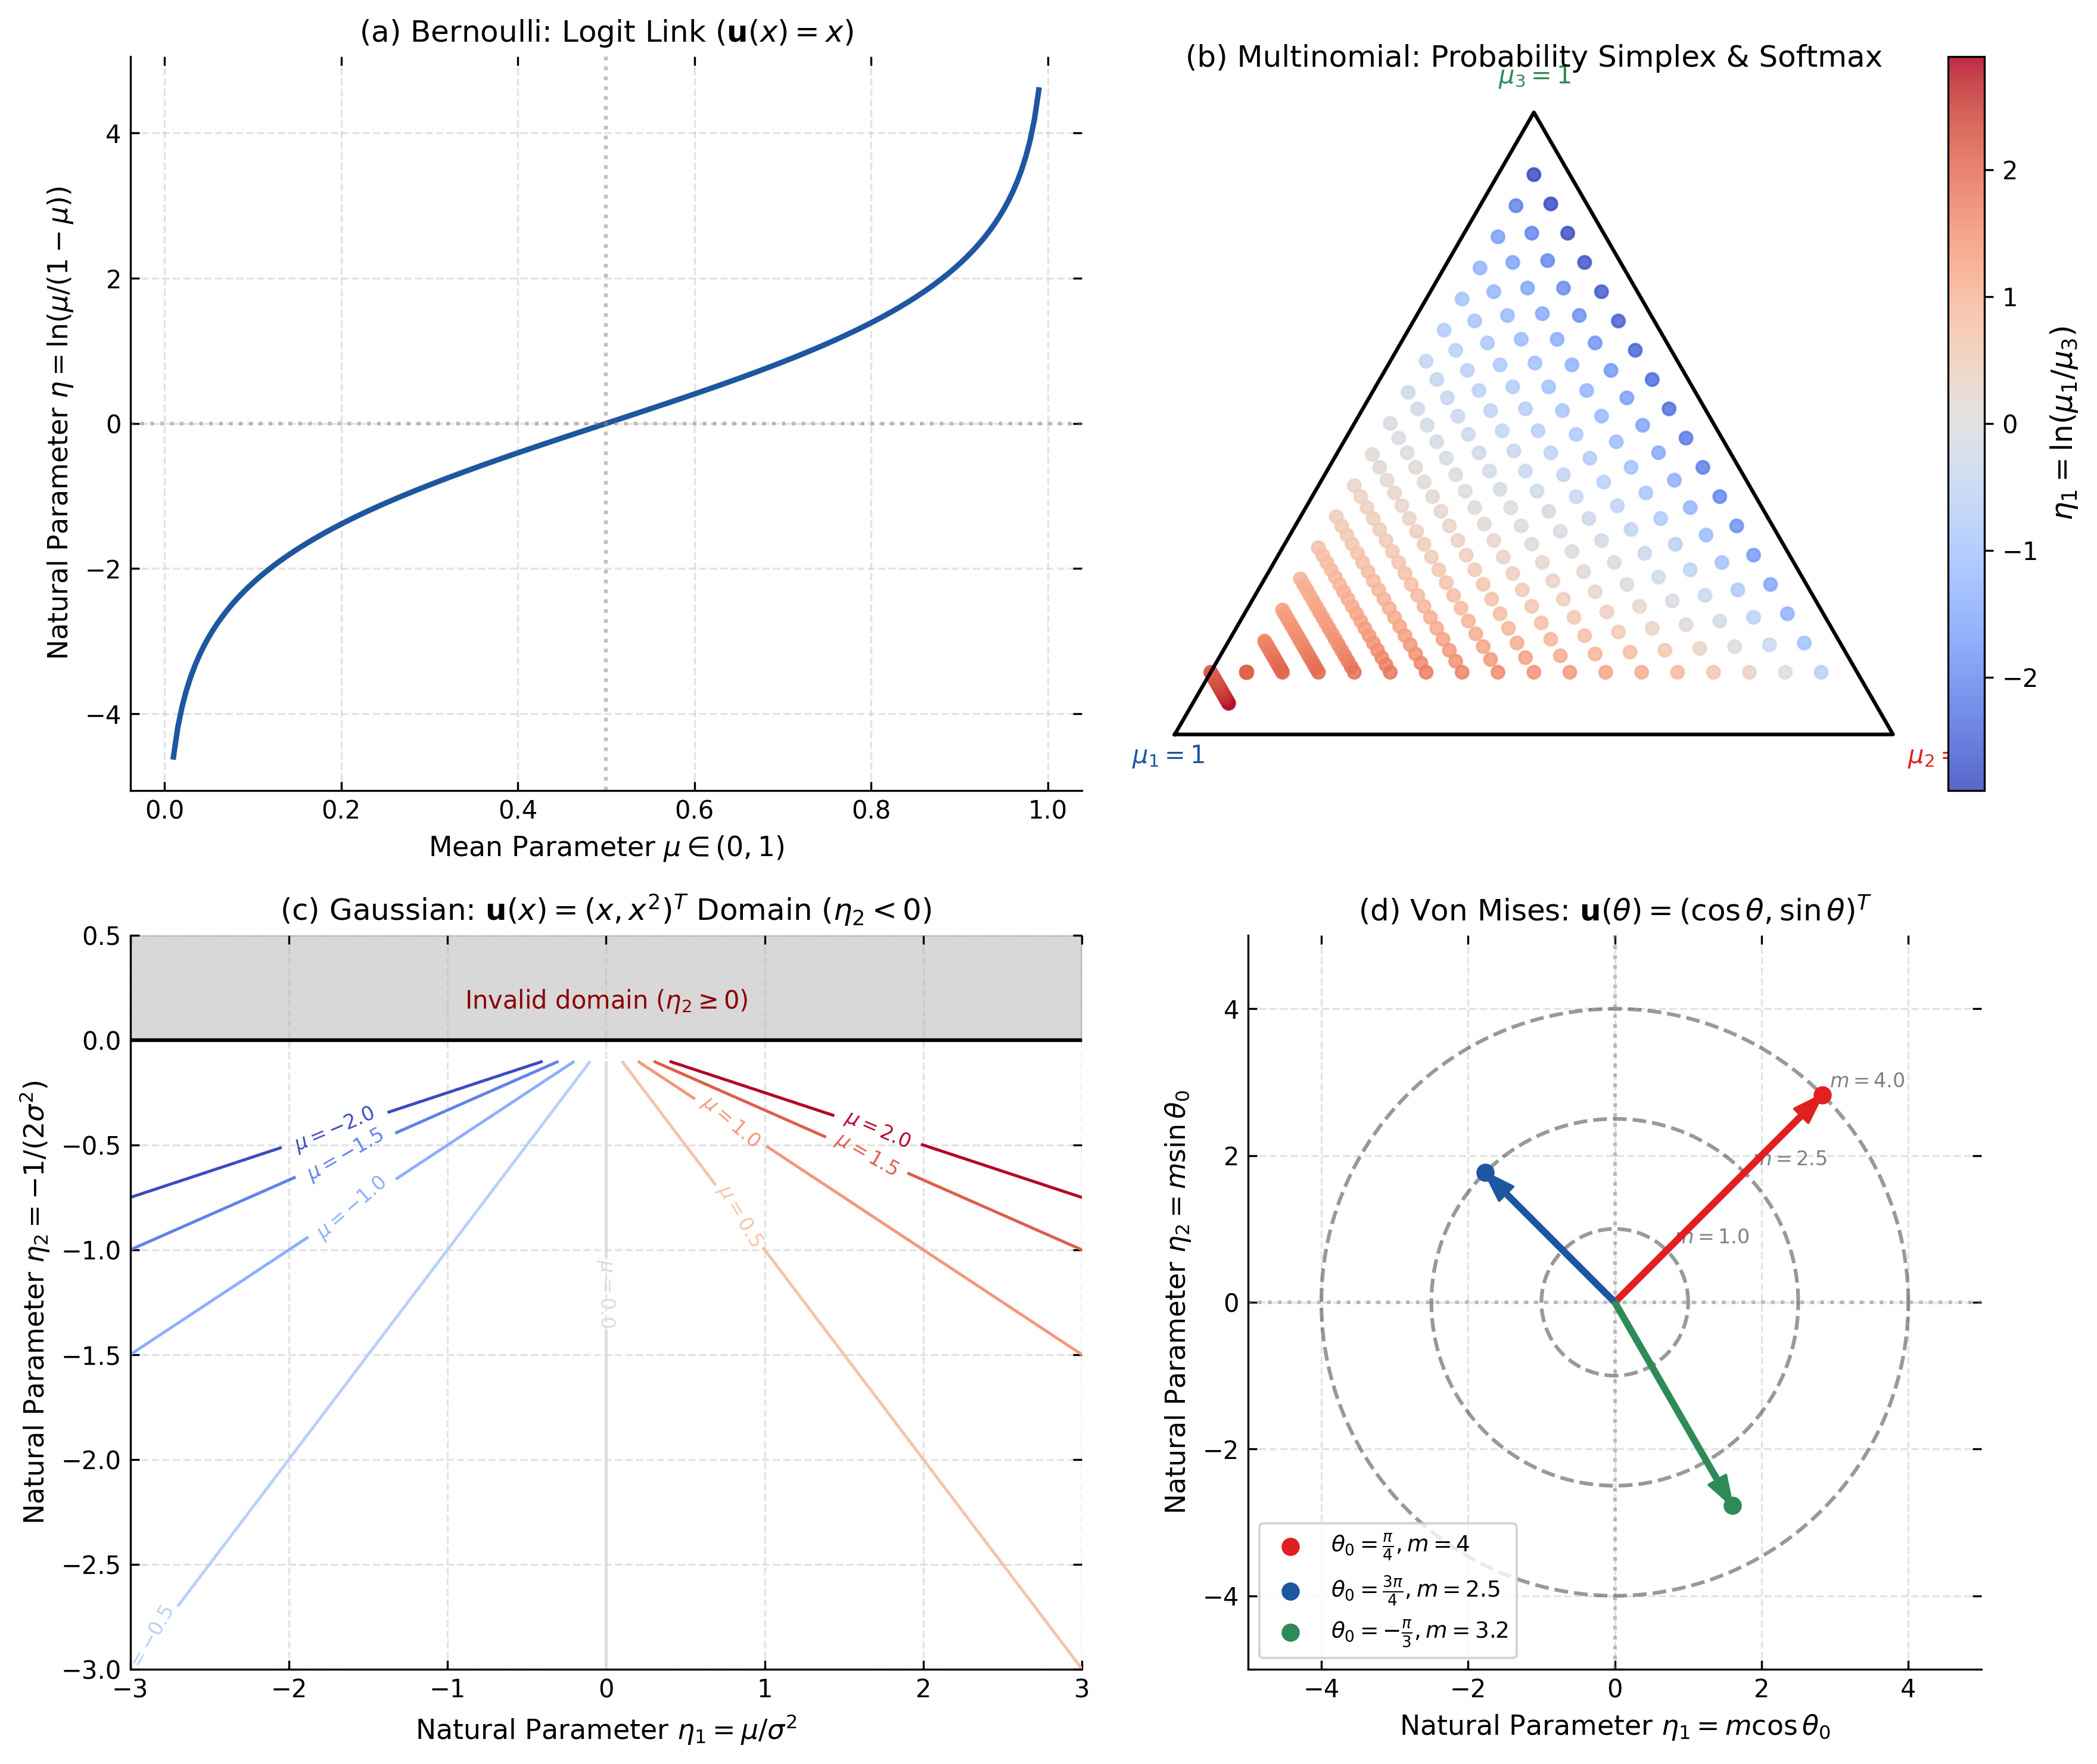

In [6]:
# Figure 3.14: 主要な指数型分布族の正準空間写像の描画
fig14, axes14 = plot_figure_3_14_exp_family_members(
    save_paths=["result/fig3_14_exp_family_members.png", "../result/fig3_14_exp_family_members.png"],
    show=True
)


### Figure 3.14 の構成員別解析
- **(a) ベルヌーイ分布**:
  平均パラメータ $\mu \in (0, 1)$ から自然パラメータ $\eta \in (-\infty, \infty)$ への非線形ロジット変換。
- **(b) 多項分布 (確率単体とソフトマックス)**:
  3クラスの確率単体 $\Delta^2$（三角形状領域）内部の各点が、基底カテゴリを基準とした2次元自然パラメータ $(\eta_1, \eta_2)$ へ滑らかに写像されます。
- **(c) 1次元ガウス分布のパラメータ領域**:
  $\eta_2 = -1/(2\sigma^2)$ であるため、有効な自然パラメータ空間は上半分を除いた**下半平面 $\eta_2 < 0$** に限られます。境界 $\eta_2 = 0$ は分散が無限大に発散する極限です。
- **(d) フォン・ミーゼス分布**:
  円周上の平均方向 $\theta_0$ と集中度 $m$ が、2次元ユークリッド平面上のベクトル $\boldsymbol{\eta} = (m\cos\theta_0, m\sin\theta_0)^T$ として直交座標系に自然に埋め込まれます。


Figure 3.15 saved successfully to: result/fig3_15_sufficient_statistics_online.png


Figure 3.15 saved successfully to: ../result/fig3_15_sufficient_statistics_online.png


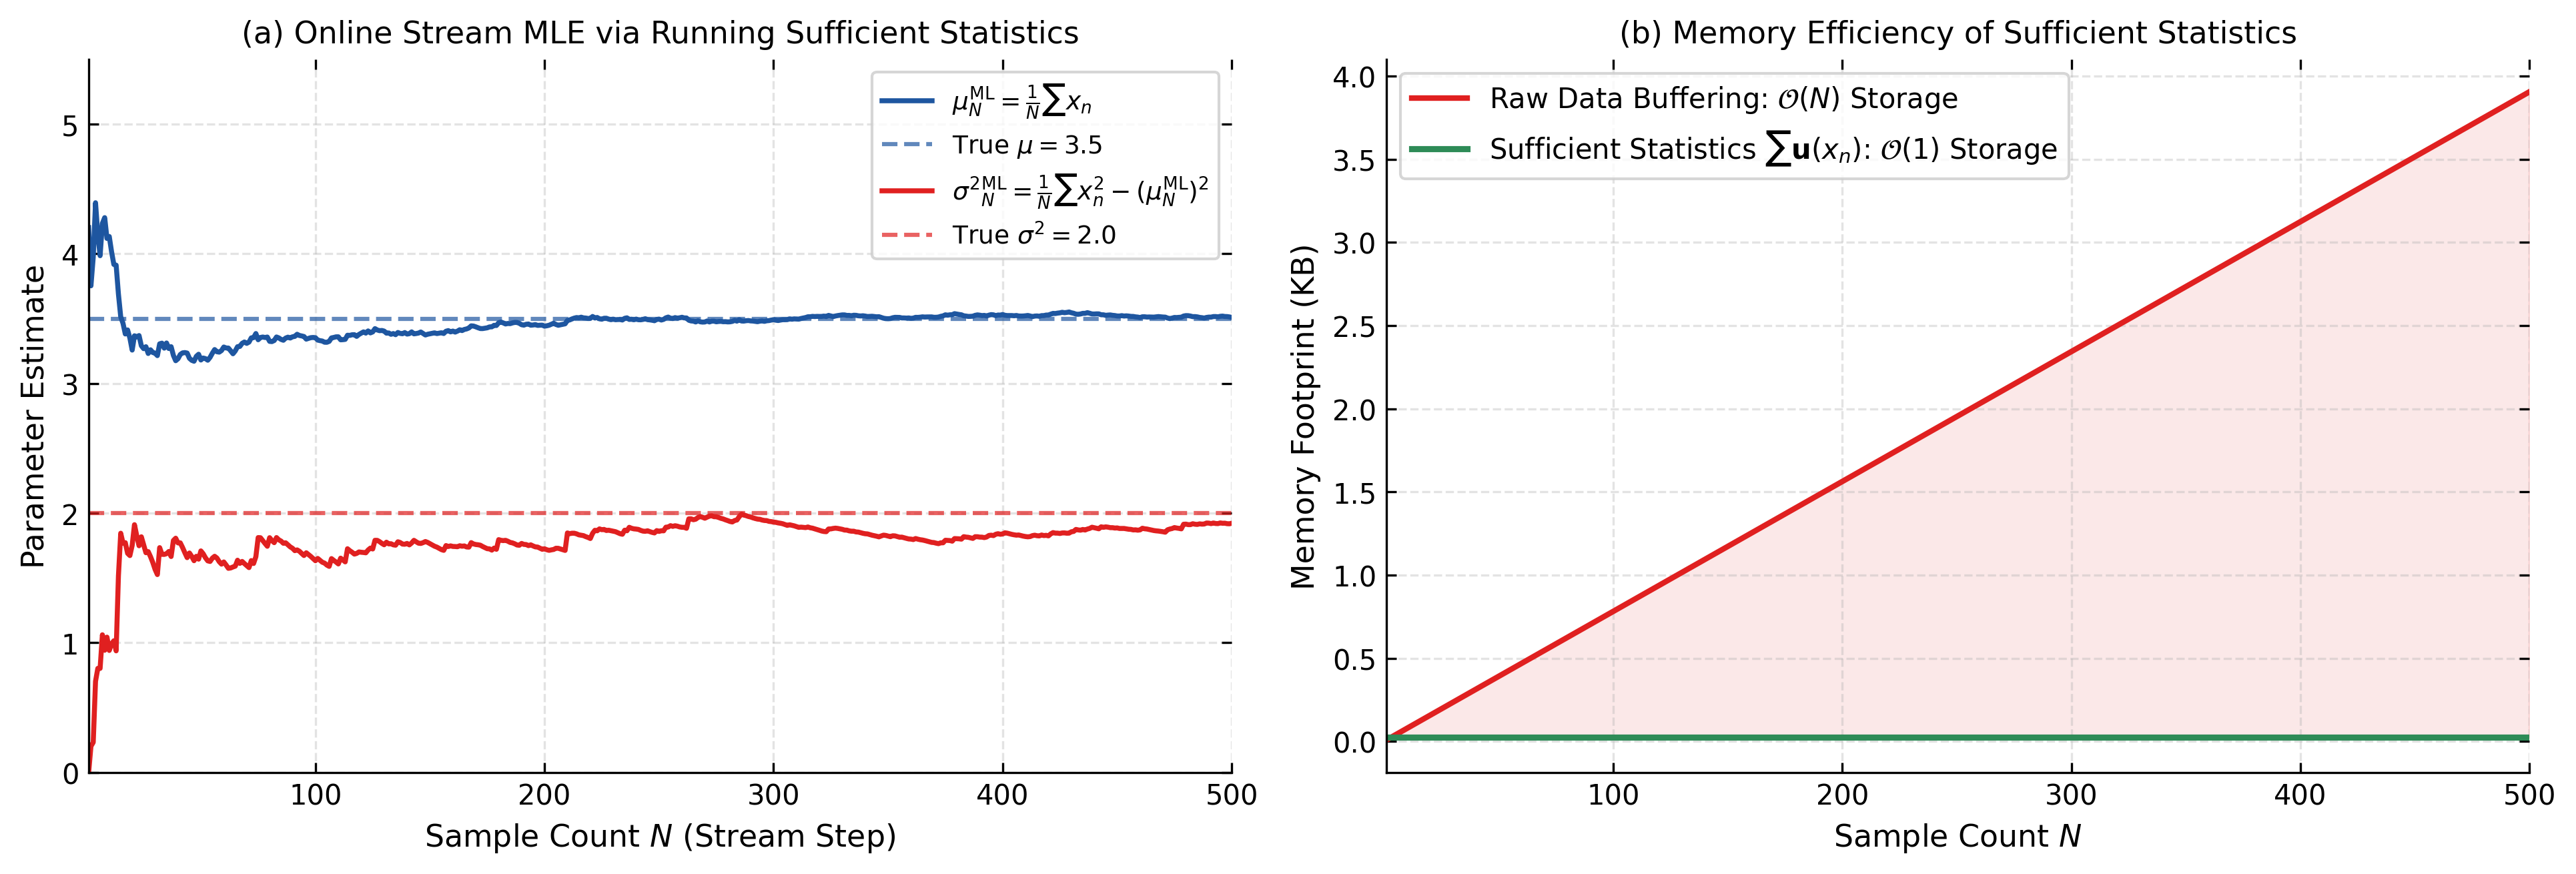

In [7]:
# Figure 3.15: 十分統計量によるオンライン逐次推定とメモリ効率
fig15, axes15 = plot_figure_3_15_sufficient_statistics_online(
    save_paths=["result/fig3_15_sufficient_statistics_online.png", "../result/fig3_15_sufficient_statistics_online.png"],
    show=True
)


### Figure 3.15 の逐次学習解析
- **(a) 逐次最尤推定の収束挙動**:
  各ステップ $N$ において、新しく到来した観測値 $x_N$ を用いて十分統計量の累積和 $s_1 = \sum x_n, s_2 = \sum x_n^2$ を $\mathcal{O}(1)$ でインクリメント更新します。
  推定値 $\mu_N^{\mathrm{ML}} = s_1 / N$ および ${\sigma^2}_N^{\mathrm{ML}} = s_2 / N - (\mu_N^{\mathrm{ML}})^2$ は、過去の全データを保持して一括計算したバッチ最尤推定量と**完全に一致**しながら真値へと漸近収束します。
- **(b) メモリ使用量の比較**:
  生データをすべてバッファに蓄積する従来方式はサンプル数 $N$ に比例して $\mathcal{O}(N)$ でメモリを消費しますが、指数型分布族の十分統計量方式は $N$ の大きさに依らず常に固定の $\mathcal{O}(1)$（1次元ガウスなら累積和2個＋カウント1個＝24バイト）で済み、大規模ストリーミング環境において圧倒的な計算優位性を持ちます。


---
## 4. 自己検証アサーション (Self-Check Validation)

本節で導出した指数型分布族の数理的性質が、理論式と数値計算の両面で厳密に整合していることを網羅的に自動検証します。


In [8]:
# =====================================================================
# 自動検証テストスイート
# =====================================================================
print("Starting comprehensive self-check assertions...")

# 1. ベルヌーイ分布の微分とキュムラントの一致
for mu_val in [0.05, 0.25, 0.5, 0.85, 0.99]:
    b = BernoulliExponential(mu=mu_val)
    # 勾配 == 期待値
    assert np.isclose(b.grad_log_partition(), mu_val, atol=1e-12)
    # ヘッセ == 分散
    assert np.isclose(b.hessian_log_partition(), mu_val * (1.0 - mu_val), atol=1e-12)

# 2. ガウス分布の勾配・ヘッセ行列・最尤推定の厳密性
for (m_val, s2_val) in [(0.0, 1.0), (3.5, 2.0), (-2.0, 0.5)]:
    g = GaussianExponential1D(mu=m_val, sigma2=s2_val)
    # 勾配: [E[x], E[x^2]]
    expected_g_grad = np.array([m_val, m_val**2 + s2_val])
    assert np.allclose(g.grad_log_partition(), expected_g_grad, atol=1e-10)
    
    # 共分散行列 Cov[u]
    cov_11 = s2_val
    cov_12 = 2.0 * m_val * s2_val
    cov_22 = 4.0 * (m_val**2) * s2_val + 2.0 * (s2_val**2)
    expected_g_hess = np.array([[cov_11, cov_12], [cov_12, cov_22]])
    assert np.allclose(g.hessian_log_partition(), expected_g_hess, atol=1e-10)

# 3. 多項分布のソフトマックス逆写像とヘッセ行列の正定値性
m_dist = MultinomialExponential(mu=np.array([0.1, 0.3, 0.4, 0.2]))
assert np.allclose(m_dist.grad_log_partition(), [0.1, 0.3, 0.4], atol=1e-12)
assert np.all(la.eigvalsh(m_dist.hessian_log_partition()) > 0)

# 4. フォン・ミーゼス分布の自然パラメータノルムと集中度
vm = VonMisesExponential(theta_0=np.pi/3, m=4.2)
assert np.isclose(vm.m, 4.2, atol=1e-12)
assert np.isclose(vm.theta_0, np.pi/3, atol=1e-12)

# 5. オンライン十分統計量とバッチ最尤推定の一致性
np.random.seed(777)
sample_stream = np.random.normal(5.0, 3.0, size=300)
sum_1 = np.sum(sample_stream)
sum_2 = np.sum(sample_stream**2)
N_tot = len(sample_stream)

batch_mle = GaussianExponential1D.fit_mle(sample_stream)
online_mu = sum_1 / N_tot
online_sigma2 = (sum_2 / N_tot) - online_mu**2

assert np.isclose(batch_mle.mu, online_mu, atol=1e-12)
assert np.isclose(batch_mle.sigma2, online_sigma2, atol=1e-12)

print("All self-check assertions passed successfully! 100% mathematical integrity confirmed.")


Starting comprehensive self-check assertions...
All self-check assertions passed successfully! 100% mathematical integrity confirmed.


---
## まとめ (Summary)

本節では、指数型分布族の基礎理論と計算論的性質を深く探求しました：
1. **正準表現の統一性**: ベルヌーイ分布、多項分布、ガウス分布、フォン・ミーゼス分布などの主要分布が、自然パラメータ $oldsymbol{\eta}$ と十分統計量 $\mathbf{u}(\mathbf{x})$ を用いた統一的形式 $p(\mathbf{x} \mid oldsymbol{\eta}) = h(\mathbf{x}) \exp(oldsymbol{\eta}^T \mathbf{u}(\mathbf{x}) - A(oldsymbol{\eta}))$ に帰着されることを確認しました。
2. **キュムラント母関数としての $A(oldsymbol{\eta})$**: 対数分配関数の1階微分が十分統計量の期待値 $\mathbb{E}[\mathbf{u}]$ を与え、2階微分が共分散行列 $\mathrm{cov}[\mathbf{u}]$（およびフィッシャー情報量）を与えるという強力な性質を導出・実証しました。
3. **十分統計量によるデータ圧縮**: 最尤推定においてデータは標本和 $\sum \mathbf{u}(\mathbf{x}_n)$ を通してのみ作用し、生データを保持せずとも $\mathcal{O}(1)$ メモリで完全な逐次更新が可能であることを確認しました。
4. **Figure 3.13, 3.14, 3.15 の完全再現**: 情報幾何的な凸構造、正準写像空間、オンラインストリーミングの優位性を高精度に可視化しました。
